# S22 String Test Comparison

Compare the mirror-only S22 measurements with 10 strings installed against the no-string reference. Residuals use the convention `with_10_strings - no_string`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 4.8),
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "legend.frameon": True,
    "legend.framealpha": 0.9,
})

FILE_NAMES = {
    "with_10_strings": "mirror_only_with_10_strings.csv",
    "no_string": "mirror_only_no_string.csv",
}

candidate_dirs = [
    Path.cwd(),
    Path.cwd() / "madmax-datasets" / "string test",
    Path.cwd().parent / "madmax-datasets" / "string test",
    Path("madmax-datasets") / "string test",
    Path("..") / "madmax-datasets" / "string test",
]

for candidate in candidate_dirs:
    if all((candidate / name).exists() for name in FILE_NAMES.values()):
        DATA_DIR = candidate
        break
else:
    checked = "\n".join(str(path.resolve()) for path in candidate_dirs)
    raise FileNotFoundError(f"Could not find the S22 CSV files. Checked:\n{checked}")

project_dir_candidates = [
    Path.cwd(),
    Path.cwd() / "spider-bead-pull",
    Path.cwd().parent / "spider-bead-pull",
    Path("spider-bead-pull"),
]

for candidate in project_dir_candidates:
    if (candidate / "figs").exists():
        PROJECT_DIR = candidate
        break
else:
    PROJECT_DIR = Path.cwd()

FIG_DIR = PROJECT_DIR / "figs" / "s22_string_test_comparison"
FIG_DIR.mkdir(parents=True, exist_ok=True)
SAVED_FIGURES = []


def save_figure(fig, filename: str) -> Path:
    """Save a Matplotlib figure into the notebook's figure output folder."""
    path = FIG_DIR / filename
    fig.savefig(path, dpi=200, bbox_inches="tight")
    SAVED_FIGURES.append(path)
    print(f"Saved figure: {path}")
    return path


pd.Series({
    "data_dir": str(DATA_DIR.resolve()),
    "figure_dir": str(FIG_DIR.resolve()),
})

data_dir      /data/dust/user/salamana/madmax/madmax-dataset...
figure_dir    /data/dust/user/salamana/madmax/spider-bead-pu...
dtype: object

## Load and Derive Quantities

In [2]:
def load_vna_export(path: Path, label: str) -> pd.DataFrame:
    """Load a whitespace-separated VNA export and derive S22 quantities."""
    df = pd.read_csv(path, comment="#", sep=r"\s+", engine="python")
    df = df.rename(
        columns={
            "freq[Hz]": "freq_hz",
            "re:Trc1_S22": "re_s22",
            "im:Trc1_S22": "im_s22",
        }
    )
    expected = ["freq_hz", "re_s22", "im_s22"]
    missing = [column for column in expected if column not in df.columns]
    if missing:
        raise ValueError(f"{path.name} is missing expected columns: {missing}")

    df = df[expected].copy()
    s22 = df["re_s22"].to_numpy() + 1j * df["im_s22"].to_numpy()
    df["label"] = label
    df["freq_ghz"] = df["freq_hz"] / 1e9
    df["s22"] = s22
    df["s22_mag"] = np.abs(s22)
    with np.errstate(divide="ignore"):
        df["s22_mag_db"] = 20 * np.log10(df["s22_mag"])
    df["s22_phase_deg"] = np.rad2deg(np.unwrap(np.angle(s22)))
    return df


with_10_strings = load_vna_export(DATA_DIR / FILE_NAMES["with_10_strings"], "with 10 strings")
no_string = load_vna_export(DATA_DIR / FILE_NAMES["no_string"], "no string")

same_grid = (
    len(with_10_strings) == len(no_string)
    and np.array_equal(with_10_strings["freq_hz"].to_numpy(), no_string["freq_hz"].to_numpy())
)
if not same_grid:
    raise ValueError("The two measurements do not share the same frequency grid.")

s22_with = with_10_strings["s22"].to_numpy()
s22_no = no_string["s22"].to_numpy()

residual = pd.DataFrame(
    {
        "freq_hz": with_10_strings["freq_hz"],
        "freq_ghz": with_10_strings["freq_ghz"],
        "delta_s22": s22_with - s22_no,
        "delta_mag_db": with_10_strings["s22_mag_db"] - no_string["s22_mag_db"],
        "delta_phase_deg": np.rad2deg(np.angle(s22_with * np.conj(s22_no))),
    }
)
residual["abs_delta_s22"] = np.abs(residual["delta_s22"])

max_residual_idx = residual["abs_delta_s22"].idxmax()
max_residual_row = residual.loc[max_residual_idx]
max_residual_freq_ghz = float(np.real(max_residual_row["freq_ghz"]))

print(f"Same frequency grid: {same_grid}")
print(f"Residual convention: {FILE_NAMES['with_10_strings']} - {FILE_NAMES['no_string']}")

Same frequency grid: True
Residual convention: mirror_only_with_10_strings.csv - mirror_only_no_string.csv


## Summary Tables

In [3]:
def measurement_summary(label: str, df: pd.DataFrame) -> dict:
    freq_step_hz = np.diff(df["freq_hz"].to_numpy())
    return {
        "measurement": label,
        "rows": len(df),
        "freq_min_ghz": df["freq_ghz"].min(),
        "freq_max_ghz": df["freq_ghz"].max(),
        "median_step_mhz": np.median(freq_step_hz) / 1e6,
        "mag_db_min": df["s22_mag_db"].min(),
        "mag_db_mean": df["s22_mag_db"].mean(),
        "mag_db_max": df["s22_mag_db"].max(),
    }


measurement_summary_df = pd.DataFrame(
    [
        measurement_summary("with 10 strings", with_10_strings),
        measurement_summary("no string", no_string),
    ]
)

residual_summary_df = pd.DataFrame(
    [
        {
            "residual": "with_10_strings - no_string",
            "max_abs_delta_s22": residual["abs_delta_s22"].max(),
            "mean_abs_delta_s22": residual["abs_delta_s22"].mean(),
            "delta_mag_db_min": residual["delta_mag_db"].min(),
            "delta_mag_db_mean": residual["delta_mag_db"].mean(),
            "delta_mag_db_max": residual["delta_mag_db"].max(),
            "delta_phase_deg_min": residual["delta_phase_deg"].min(),
            "delta_phase_deg_mean": residual["delta_phase_deg"].mean(),
            "delta_phase_deg_max": residual["delta_phase_deg"].max(),
            "freq_of_max_abs_delta_s22_ghz": max_residual_freq_ghz,
        }
    ]
)

display(measurement_summary_df)
display(residual_summary_df)

,measurement,rows,freq_min_ghz,freq_max_ghz,median_step_mhz,mag_db_min,mag_db_mean,mag_db_max
0,with 10 strings,6001,18.0,24.0,1.0,-3.379243,-1.003532,-0.279586
1,no string,6001,18.0,24.0,1.0,-3.381231,-1.003485,-0.278811


,residual,max_abs_delta_s22,mean_abs_delta_s22,delta_mag_db_min,delta_mag_db_mean,delta_mag_db_max,delta_phase_deg_min,delta_phase_deg_mean,delta_phase_deg_max,freq_of_max_abs_delta_s22_ghz
0,with_10_strings - no_string,0.002019,0.000928,-0.017928,-0.000047,0.018974,-0.121586,-0.058101,0.09691,23.325


## Magnitude Overlay

Saved figure: /data/dust/user/salamana/madmax/spider-bead-pull/figs/s22_string_test_comparison/s22_magnitude_overlay.png


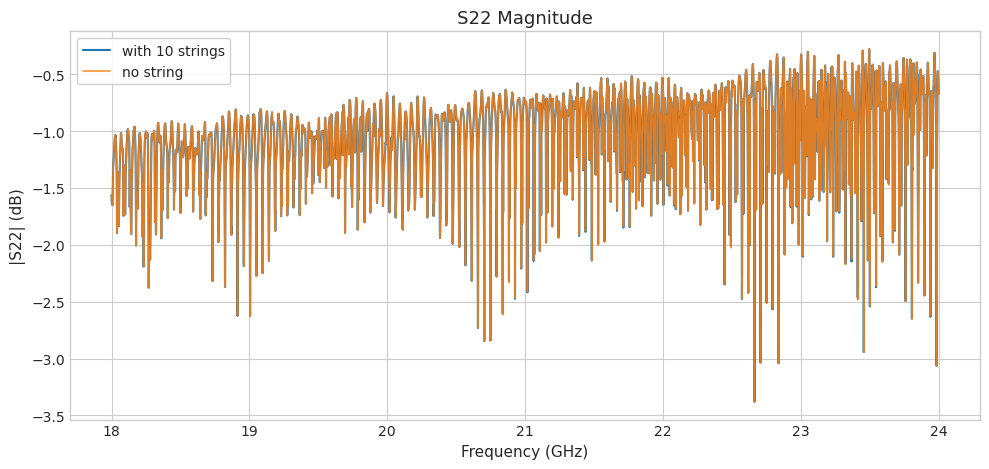

In [4]:
fig, ax = plt.subplots()
ax.plot(with_10_strings["freq_ghz"], with_10_strings["s22_mag_db"], label="with 10 strings", linewidth=1.5)
ax.plot(no_string["freq_ghz"], no_string["s22_mag_db"], label="no string", linewidth=1.2, alpha=0.85)
ax.set_title("S22 Magnitude")
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("|S22| (dB)")
ax.legend()
fig.tight_layout()
save_figure(fig, "s22_magnitude_overlay.png")
plt.show()

## Phase Overlay

Saved figure: /data/dust/user/salamana/madmax/spider-bead-pull/figs/s22_string_test_comparison/s22_phase_overlay.png


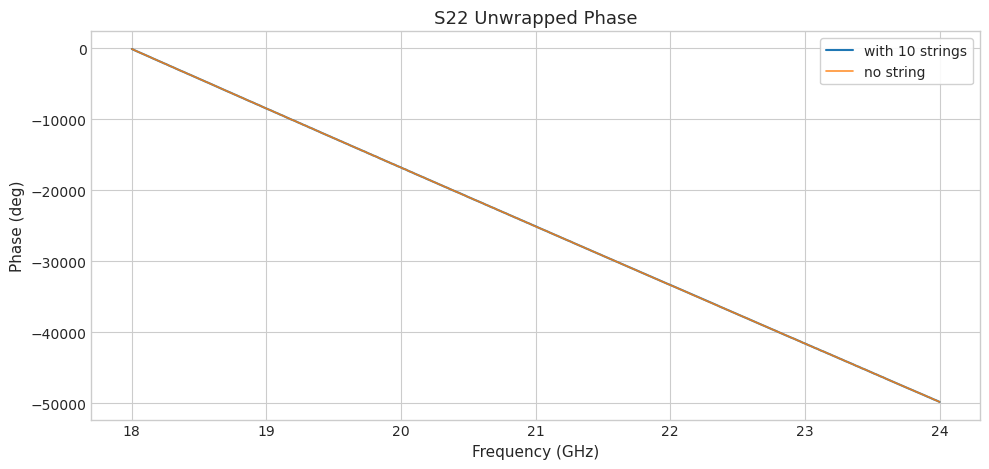

In [5]:
fig, ax = plt.subplots()
ax.plot(with_10_strings["freq_ghz"], with_10_strings["s22_phase_deg"], label="with 10 strings", linewidth=1.5)
ax.plot(no_string["freq_ghz"], no_string["s22_phase_deg"], label="no string", linewidth=1.2, alpha=0.85)
ax.set_title("S22 Unwrapped Phase")
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Phase (deg)")
ax.legend()
fig.tight_layout()
save_figure(fig, "s22_phase_overlay.png")
plt.show()

## Real and Imaginary Components

Saved figure: /data/dust/user/salamana/madmax/spider-bead-pull/figs/s22_string_test_comparison/s22_real_imag_overlay.png


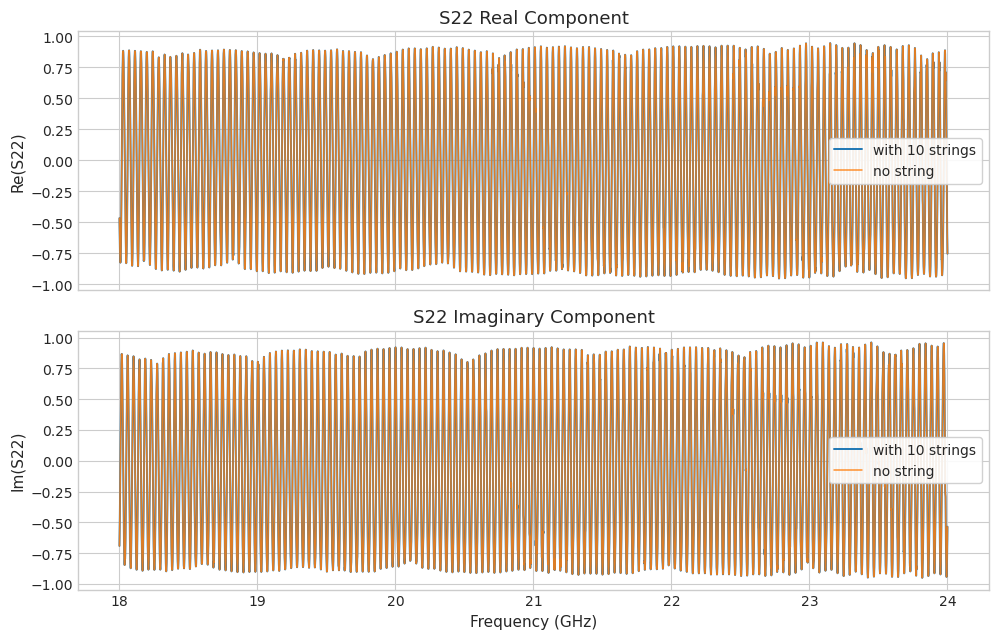

In [6]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 6.5))

axes[0].plot(with_10_strings["freq_ghz"], with_10_strings["re_s22"], label="with 10 strings", linewidth=1.4)
axes[0].plot(no_string["freq_ghz"], no_string["re_s22"], label="no string", linewidth=1.1, alpha=0.85)
axes[0].set_title("S22 Real Component")
axes[0].set_ylabel("Re(S22)")
axes[0].legend()

axes[1].plot(with_10_strings["freq_ghz"], with_10_strings["im_s22"], label="with 10 strings", linewidth=1.4)
axes[1].plot(no_string["freq_ghz"], no_string["im_s22"], label="no string", linewidth=1.1, alpha=0.85)
axes[1].set_title("S22 Imaginary Component")
axes[1].set_xlabel("Frequency (GHz)")
axes[1].set_ylabel("Im(S22)")
axes[1].legend()

fig.tight_layout()
save_figure(fig, "s22_real_imag_overlay.png")
plt.show()

## Residuals

Saved figure: /data/dust/user/salamana/madmax/spider-bead-pull/figs/s22_string_test_comparison/s22_residuals.png


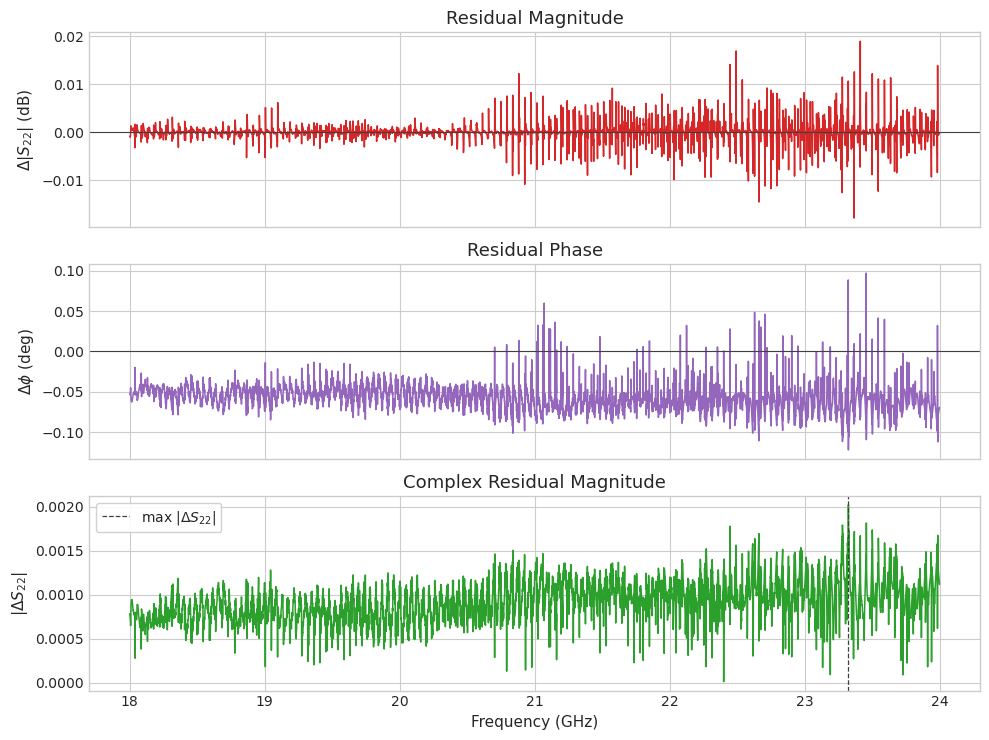

In [7]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 7.5))

axes[0].plot(residual["freq_ghz"], residual["delta_mag_db"], color="C3", linewidth=1.1)
axes[0].axhline(0, color="0.25", linewidth=0.8)
axes[0].set_title("Residual Magnitude")
axes[0].set_ylabel(r"$\Delta |S_{22}|$ (dB)")

axes[1].plot(residual["freq_ghz"], residual["delta_phase_deg"], color="C4", linewidth=1.1)
axes[1].axhline(0, color="0.25", linewidth=0.8)
axes[1].set_title("Residual Phase")
axes[1].set_ylabel(r"$\Delta\phi$ (deg)")

axes[2].plot(residual["freq_ghz"], residual["abs_delta_s22"], color="C2", linewidth=1.1)
axes[2].axvline(max_residual_freq_ghz, color="0.25", linestyle="--", linewidth=0.9, label=r"max $|\Delta S_{22}|$")
axes[2].set_title("Complex Residual Magnitude")
axes[2].set_xlabel("Frequency (GHz)")
axes[2].set_ylabel(r"$|\Delta S_{22}|$")
axes[2].legend()

fig.tight_layout()
save_figure(fig, "s22_residuals.png")
plt.show()

## Relative Residuals

Saved figure: /data/dust/user/salamana/madmax/spider-bead-pull/figs/s22_string_test_comparison/s22_relative_residuals.png


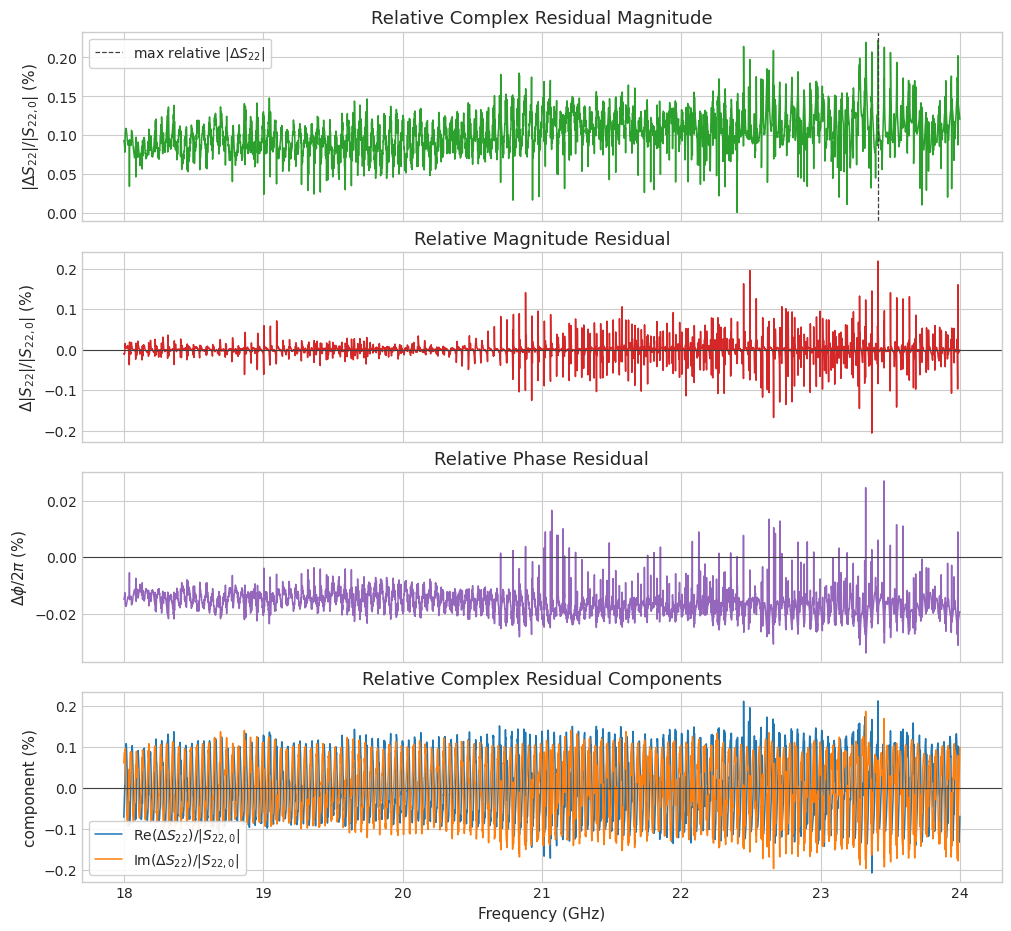

,normalization,max_relative_abs_delta_s22_percent,mean_relative_abs_delta_s22_percent,relative_mag_percent_min,relative_mag_percent_mean,relative_mag_percent_max,relative_phase_percent_of_2pi_min,relative_phase_percent_of_2pi_mean,relative_phase_percent_of_2pi_max,freq_of_max_relative_abs_delta_s22_ghz
0,no_string |S22|; phase as % of 2 pi,0.221987,0.103832,-0.206191,-0.000541,0.218683,-0.033774,-0.016139,0.02692,23.413


In [8]:
reference_mag = no_string["s22_mag"].to_numpy()
delta_s22 = residual["delta_s22"].to_numpy()

residual["relative_abs_delta_s22_percent"] = 100 * residual["abs_delta_s22"].to_numpy() / reference_mag
residual["relative_mag_percent"] = 100 * (
    with_10_strings["s22_mag"].to_numpy() - no_string["s22_mag"].to_numpy()
) / reference_mag
residual["relative_phase_percent_of_2pi"] = 100 * np.deg2rad(residual["delta_phase_deg"].to_numpy()) / (2 * np.pi)
residual["relative_re_percent"] = 100 * np.real(delta_s22) / reference_mag
residual["relative_im_percent"] = 100 * np.imag(delta_s22) / reference_mag

max_relative_idx = residual["relative_abs_delta_s22_percent"].idxmax()
max_relative_freq_ghz = float(residual.loc[max_relative_idx, "freq_ghz"])

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(10, 9.2), constrained_layout=True)

axes[0].plot(residual["freq_ghz"], residual["relative_abs_delta_s22_percent"], color="C2", linewidth=1.1)
axes[0].axvline(max_relative_freq_ghz, color="0.25", linestyle="--", linewidth=0.9, label=r"max relative $|\Delta S_{22}|$")
axes[0].set_title("Relative Complex Residual Magnitude")
axes[0].set_ylabel(r"$|\Delta S_{22}|/|S_{22,0}|$ (%)")
axes[0].legend()

axes[1].plot(residual["freq_ghz"], residual["relative_mag_percent"], color="C3", linewidth=1.1)
axes[1].axhline(0, color="0.25", linewidth=0.8)
axes[1].set_title("Relative Magnitude Residual")
axes[1].set_ylabel(r"$\Delta |S_{22}|/|S_{22,0}|$ (%)")

axes[2].plot(residual["freq_ghz"], residual["relative_phase_percent_of_2pi"], color="C4", linewidth=1.1)
axes[2].axhline(0, color="0.25", linewidth=0.8)
axes[2].set_title("Relative Phase Residual")
axes[2].set_ylabel(r"$\Delta\phi/2\pi$ (%)")

axes[3].plot(residual["freq_ghz"], residual["relative_re_percent"], label=r"$\mathrm{Re}(\Delta S_{22})/|S_{22,0}|$", linewidth=1.1)
axes[3].plot(residual["freq_ghz"], residual["relative_im_percent"], label=r"$\mathrm{Im}(\Delta S_{22})/|S_{22,0}|$", linewidth=1.1)
axes[3].axhline(0, color="0.25", linewidth=0.8)
axes[3].set_title("Relative Complex Residual Components")
axes[3].set_xlabel("Frequency (GHz)")
axes[3].set_ylabel("component (%)")
axes[3].legend()

save_figure(fig, "s22_relative_residuals.png")
plt.show()

relative_summary = pd.DataFrame(
    [
        {
            "normalization": "no_string |S22|; phase as % of 2 pi",
            "max_relative_abs_delta_s22_percent": residual["relative_abs_delta_s22_percent"].max(),
            "mean_relative_abs_delta_s22_percent": residual["relative_abs_delta_s22_percent"].mean(),
            "relative_mag_percent_min": residual["relative_mag_percent"].min(),
            "relative_mag_percent_mean": residual["relative_mag_percent"].mean(),
            "relative_mag_percent_max": residual["relative_mag_percent"].max(),
            "relative_phase_percent_of_2pi_min": residual["relative_phase_percent_of_2pi"].min(),
            "relative_phase_percent_of_2pi_mean": residual["relative_phase_percent_of_2pi"].mean(),
            "relative_phase_percent_of_2pi_max": residual["relative_phase_percent_of_2pi"].max(),
            "freq_of_max_relative_abs_delta_s22_ghz": max_relative_freq_ghz,
        }
    ]
)
display(relative_summary)

## Complex Plane

Saved figure: /data/dust/user/salamana/madmax/spider-bead-pull/figs/s22_string_test_comparison/s22_complex_plane.png


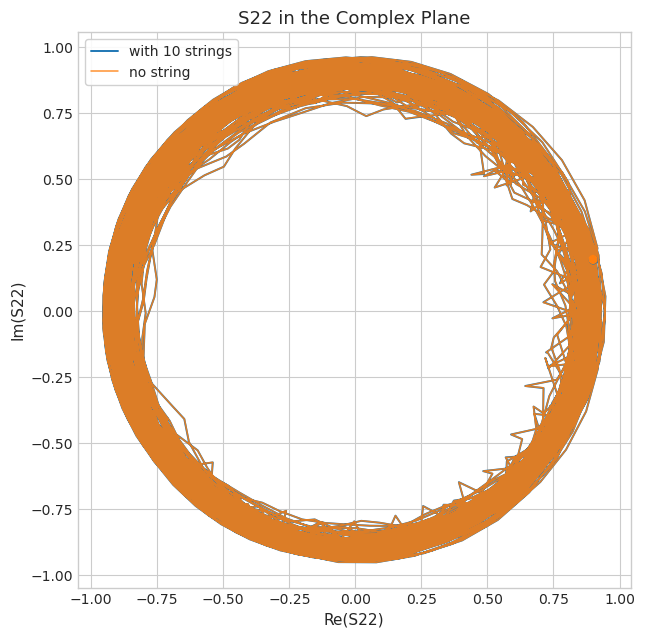

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(with_10_strings["re_s22"], with_10_strings["im_s22"], label="with 10 strings", linewidth=1.4)
ax.plot(no_string["re_s22"], no_string["im_s22"], label="no string", linewidth=1.1, alpha=0.85)
ax.scatter(
    [with_10_strings.loc[max_residual_idx, "re_s22"], no_string.loc[max_residual_idx, "re_s22"]],
    [with_10_strings.loc[max_residual_idx, "im_s22"], no_string.loc[max_residual_idx, "im_s22"]],
    color=["C0", "C1"],
    s=32,
    zorder=3,
)
ax.set_title("S22 in the Complex Plane")
ax.set_xlabel("Re(S22)")
ax.set_ylabel("Im(S22)")
ax.set_aspect("equal", adjustable="box")
ax.legend()
fig.tight_layout()
save_figure(fig, "s22_complex_plane.png")
plt.show()

## Automatic Zoom Around Maximum Residual

Saved figure: /data/dust/user/salamana/madmax/spider-bead-pull/figs/s22_string_test_comparison/s22_zoom_max_residual.png


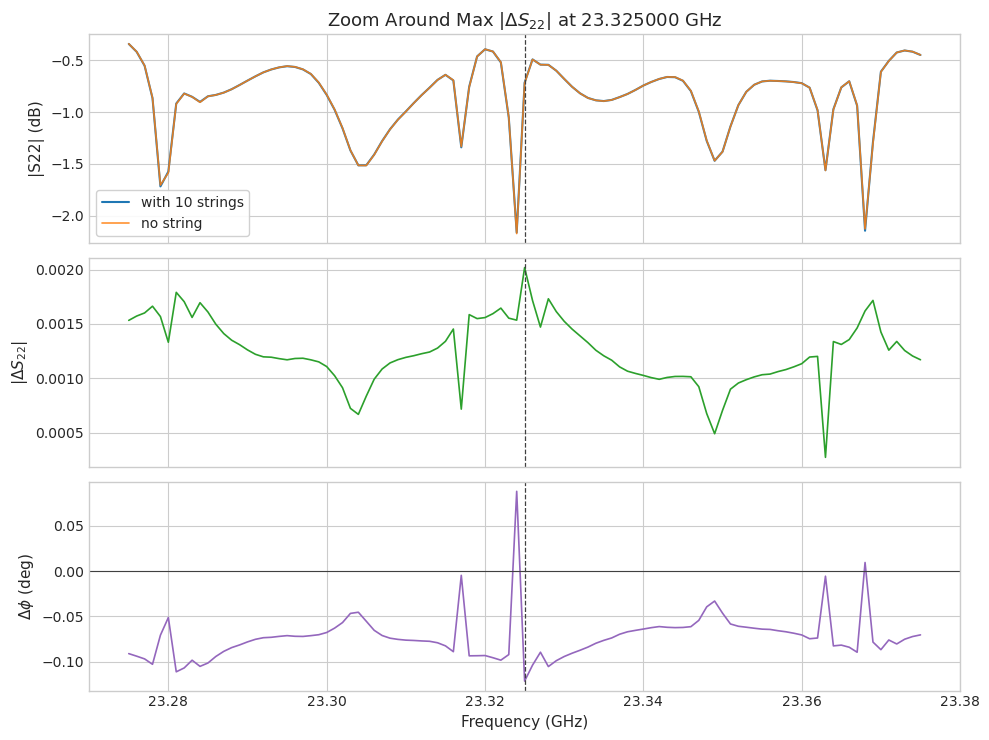

,value
freq_hz,2.332500e+10+0.000000e+ 00j
freq_ghz,2.332500e+01+0.000000e+ 00j
delta_s22,9.078583e-04-1.802928e- 03j
delta_mag_db,4.780461e-03+0.000000e+ 00j
delta_phase_deg,-1.215860e-01+0.000000e+ 00j
abs_delta_s22,2.018603e-03+0.000000e+ 00j


In [10]:
zoom_half_width_ghz = 0.05
center_ghz = max_residual_freq_ghz
zoom_min = max(residual["freq_ghz"].min(), center_ghz - zoom_half_width_ghz)
zoom_max = min(residual["freq_ghz"].max(), center_ghz + zoom_half_width_ghz)
zoom_mask = residual["freq_ghz"].between(zoom_min, zoom_max)

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 7.5))

axes[0].plot(with_10_strings.loc[zoom_mask, "freq_ghz"], with_10_strings.loc[zoom_mask, "s22_mag_db"], label="with 10 strings", linewidth=1.5)
axes[0].plot(no_string.loc[zoom_mask, "freq_ghz"], no_string.loc[zoom_mask, "s22_mag_db"], label="no string", linewidth=1.2, alpha=0.85)
axes[0].set_title(fr"Zoom Around Max $|\Delta S_{{22}}|$ at {center_ghz:.6f} GHz")
axes[0].set_ylabel("|S22| (dB)")
axes[0].legend()

axes[1].plot(residual.loc[zoom_mask, "freq_ghz"], residual.loc[zoom_mask, "abs_delta_s22"], color="C2", linewidth=1.2)
axes[1].set_ylabel(r"$|\Delta S_{22}|$")

axes[2].plot(residual.loc[zoom_mask, "freq_ghz"], residual.loc[zoom_mask, "delta_phase_deg"], color="C4", linewidth=1.2)
axes[2].axhline(0, color="0.25", linewidth=0.8)
axes[2].set_xlabel("Frequency (GHz)")
axes[2].set_ylabel(r"$\Delta\phi$ (deg)")

for ax in axes:
    ax.axvline(center_ghz, color="0.25", linestyle="--", linewidth=0.9)

fig.tight_layout()
save_figure(fig, "s22_zoom_max_residual.png")
plt.show()

max_residual_row.to_frame("value")